In [1]:
#Program Name: Homework Assignment 1
#Program Author: K.Roller
#Date Created: August 7th 2024
#Program Purpose: To read in donor.csv file, clean data as appropriate and perform some level of analysis on the data
#
#
#
# To begin will start by loading in some of the libraries we will be using
import pandas as pd 
import numpy as np
import seaborn as sns

In [2]:
#Selecting the file path of the downloaded dataset located on the local machine
file_path="C:/Users/super/Downloads/donors_data.csv"
#Saving the data as a data frame
donors=pd.read_csv(file_path)

In [3]:
print(donors.head())

   Row Id  Row Id.  zipconvert_2  zipconvert_3  zipconvert_4  zipconvert_5  \
0       1       17             0             1             0             0   
1       2       25             1             0             0             0   
2       3       29             0             0             0             1   
3       4       38             0             0             0             1   
4       5       40             0             1             0             0   

   homeowner dummy  NUMCHLD  INCOME  gender dummy  ...  IC15  NUMPROM  \
0                1        1       5             1  ...     1       74   
1                1        1       1             0  ...     4       46   
2                0        2       5             1  ...    13       32   
3                1        1       3             0  ...     4       94   
4                1        1       4             0  ...     7       20   

   RAMNTALL  MAXRAMNT  LASTGIFT  totalmonths  TIMELAG   AVGGIFT  TARGET_B  \
0     102.0    

In [4]:
#Checking the data types that were created when making the dataframe
print(donors.dtypes)

Row Id               int64
Row Id.              int64
zipconvert_2         int64
zipconvert_3         int64
zipconvert_4         int64
zipconvert_5         int64
homeowner dummy      int64
NUMCHLD              int64
INCOME               int64
gender dummy         int64
WEALTH               int64
HV                   int64
Icmed                int64
Icavg                int64
IC15                 int64
NUMPROM              int64
RAMNTALL           float64
MAXRAMNT           float64
LASTGIFT           float64
totalmonths          int64
TIMELAG              int64
AVGGIFT            float64
TARGET_B             int64
TARGET_D           float64
dtype: object


In [5]:
#OK, so now we can see some changes need to be made to the data if any meaningful analysis is to take place. 
#For starters, there are several categorical variables currently stored as integers, such as gender dummy 
# or homeowner dummy. Additionally, Row ID will probably serve little function unless we needed an index. 
#For now, we will convert the variables that require conversion to the appropriate data type. 

#To convert the data type, will use pd function to do so 
donors["homeowner dummy"]=pd.Categorical(donors["homeowner dummy"])

In [6]:
#Now to check that the appropriate conversion occured
print(donors.dtypes)

Row Id                int64
Row Id.               int64
zipconvert_2          int64
zipconvert_3          int64
zipconvert_4          int64
zipconvert_5          int64
homeowner dummy    category
NUMCHLD               int64
INCOME                int64
gender dummy          int64
WEALTH                int64
HV                    int64
Icmed                 int64
Icavg                 int64
IC15                  int64
NUMPROM               int64
RAMNTALL            float64
MAXRAMNT            float64
LASTGIFT            float64
totalmonths           int64
TIMELAG               int64
AVGGIFT             float64
TARGET_B              int64
TARGET_D            float64
dtype: object


In [7]:
#Conversion of datatype applied correctly, now for the other variables
#...
#..
#Before moving further, going to fix this white screen
#!pip install jupyterthemes

In [16]:
#from jupyterthemes import get_themes
#import jupyterthemes as jt
#from jupyterthemes.stylefx import set_nb_theme
#set_nb_theme('monokai')


In [17]:
#now to perform conversion on the rest of the variables 
donors["gender dummy"]=pd.Categorical(donors["gender dummy"])
donors["zipconvert_2"]=pd.Categorical(donors["zipconvert_2"])
donors["zipconvert_3"]=pd.Categorical(donors["zipconvert_3"])
donors["zipconvert_4"]=pd.Categorical(donors["zipconvert_4"])
donors["zipconvert_5"]=pd.Categorical(donors["zipconvert_5"])



In [18]:
#Now to recheck the dataset and verify changes once again
print(donors.dtypes)

Row Id                int64
Row Id.               int64
zipconvert_2       category
zipconvert_3       category
zipconvert_4       category
zipconvert_5       category
homeowner dummy    category
NUMCHLD               int64
INCOME                int64
gender dummy       category
WEALTH                int64
HV                    int64
Icmed                 int64
Icavg                 int64
IC15                  int64
NUMPROM               int64
RAMNTALL            float64
MAXRAMNT            float64
LASTGIFT            float64
totalmonths           int64
TIMELAG               int64
AVGGIFT             float64
TARGET_B              int64
TARGET_D            float64
dtype: object


In [24]:
#ah, and according to the data dictionary zip convert is not needed for this analysis,
# so it along with the row id variables should be removed from the dataset in order 
# to reduce dimensionality of the data. 
donors=donors.drop(["Row Id", "Row Id.", "zipconvert_2","zipconvert_3","zipconvert_4","zipconvert_5" ], axis=1)
print(donors.dtypes)

homeowner dummy    category
NUMCHLD               int64
INCOME                int64
gender dummy       category
WEALTH                int64
HV                    int64
Icmed                 int64
Icavg                 int64
IC15                  int64
NUMPROM               int64
RAMNTALL            float64
MAXRAMNT            float64
LASTGIFT            float64
totalmonths           int64
TIMELAG               int64
AVGGIFT             float64
TARGET_B              int64
TARGET_D            float64
dtype: object


In [25]:
print(donors.head())

  homeowner dummy  NUMCHLD  INCOME gender dummy  WEALTH    HV  Icmed  Icavg  \
5               1        1       4            1       8   482    242    275   
6               1        1       4            1       8   857    450    498   
7               1        1       1            0       7  1355    411    497   
8               1        1       4            0       5   505    333    388   
9               1        1       4            1       8  1438    458    533   

   IC15  NUMPROM  RAMNTALL  MAXRAMNT  LASTGIFT  totalmonths  TIMELAG  \
5    28       38      73.0      10.0      10.0           31        3   
6     5       47     139.0      20.0      20.0           37        3   
7     9       77     249.0      15.0       7.0           35        3   
8    16       51      63.0      15.0      10.0           37        8   
9     8       21      26.0      16.0      16.0           30        6   

     AVGGIFT  TARGET_B  TARGET_D  
5   7.300000         1       8.0  
6  10.692308         1

In [26]:
#OK, unneeded columns are no longer present in the dataset, but need to check for na values
#Create a variable to store the counts in 
na_count=donors.isna().sum()
#do the same for NULL values 
null_count=donors.isnull().sum()
#Return the counts for each by printing the variable 
print(na_count)
print(null_count)

homeowner dummy    0
NUMCHLD            0
INCOME             0
gender dummy       0
WEALTH             0
HV                 0
Icmed              0
Icavg              0
IC15               0
NUMPROM            0
RAMNTALL           0
MAXRAMNT           0
LASTGIFT           0
totalmonths        0
TIMELAG            0
AVGGIFT            0
TARGET_B           0
TARGET_D           0
dtype: int64
homeowner dummy    0
NUMCHLD            0
INCOME             0
gender dummy       0
WEALTH             0
HV                 0
Icmed              0
Icavg              0
IC15               0
NUMPROM            0
RAMNTALL           0
MAXRAMNT           0
LASTGIFT           0
totalmonths        0
TIMELAG            0
AVGGIFT            0
TARGET_B           0
TARGET_D           0
dtype: int64


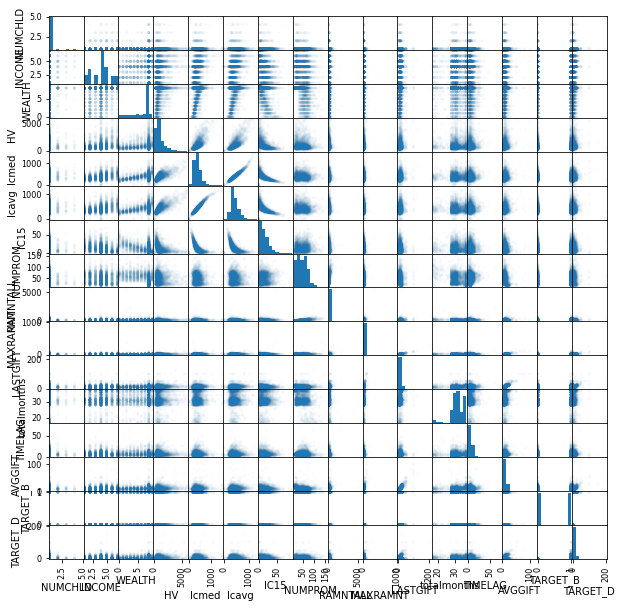

In [30]:
#OK, so no NA or NULL values to contend with before moving on to the analysis stage. 
#First we will start by looking at how the data is distributed via some simple plots
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
#Using pandas to create a scatter matrix similar to R's plot(dataframe) function
scatter_matrix(donors, alpha=0.02, figsize=(10,10), diagonal="hist")
plt.show()

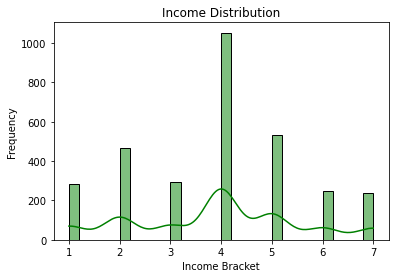

In [33]:
#Create some histograms to get a closer look at some of the values
#Using sns function histplot to make histograms of several variables
#bins was left set at 30 because if it needed less it will use less, but normally what I default to
#Tried to change colors between plots to make them differentiable. 
sns.histplot(donors['INCOME'], kde=True, bins=30, color="green")
#Label the plot title
plt.title("Income Distribution")
#Label the axis 
plt.xlabel("Income Bracket")
plt.ylabel("Frequency")
#display the plot
plt.show()

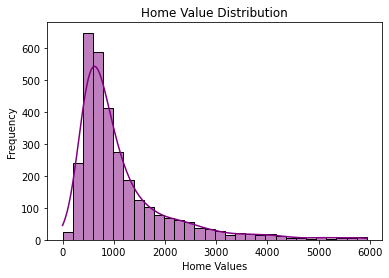

In [35]:
#It looks like within this dataset the mean and median should be close to one another. 
# Most of the observations are in income bracket 4, though the data is not 
# perfectly normally distributed. 

#Code used here is the same as first hist, so will not recomment every histogram
sns.histplot(donors["HV"], kde=True, bins=30, color="purple")
plt.title("Home Value Distribution")
plt.xlabel("Home Values")
plt.ylabel("Frequency")
plt.show()


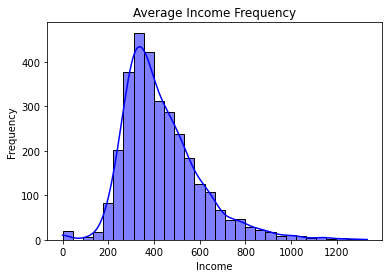

In [36]:
#This data has a rightward skew, with most of the home values around 1000, this is assumed to be in hundreds
# but since not specified in the data dictionary will make no claims as to what this value is supposed to be

sns.histplot(donors["Icavg"], kde=True, bins=30, color="blue")
plt.title("Average Income Frequency")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

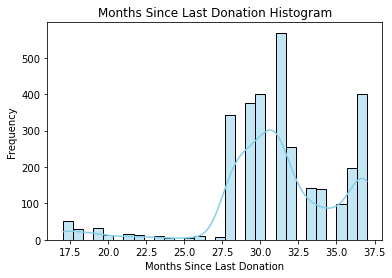

In [37]:
#Here we once again see a rightward skew in the data, if we were to use a model such as linear regression 
# we would need to transform these variables before proceeding

sns.histplot(donors["totalmonths"], kde=True, bins=30, color="skyblue")
plt.title("Months Since Last Donation Histogram")
plt.xlabel("Months Since Last Donation")
plt.ylabel("Frequency")
plt.show()

In [38]:
#And here we can see the cause for why this data set was probably created in the first place. 
# A large leftward skew can be seen here indicating that the vast majority of donators have 
# not made a donation in some time. So, we need to figure out, what group of donators makes 
# large donations, whichs ones have not made one in a while, and what group of new donators can 
# be appealed to in order to increase donations. 

In [48]:
#First, lets take a look at what households with children look like in time since last donation
#Using the group by function to group the total number of months by child count
#and storing it in a variable
child_donation_time=donors.groupby("NUMCHLD")["totalmonths"].mean()
#Printing the variable 
print(child_donation_time)

NUMCHLD
1    31.141509
2    31.265306
3    30.000000
4    31.882353
5    31.000000
Name: totalmonths, dtype: float64


In [41]:
#Same as above, using group by but this time looking at the avggift amount per child count
avg_gift_by_child=donors.groupby("NUMCHLD")["AVGGIFT"].mean()
print(avg_income_by_child)

NUMCHLD
1    430.248315
2    458.908163
3    461.290323
4    512.529412
5    632.000000
Name: Icavg, dtype: float64


In [46]:
#.....Should have converted some addtional variables...
donors["WEALTH"]=pd.Categorical(donors["WEALTH"])
donors["INCOME"]=pd.Categorical(donors["INCOME"])

In [47]:
print(donors.dtypes)

homeowner dummy    category
NUMCHLD               int64
INCOME             category
gender dummy       category
WEALTH             category
HV                    int64
Icmed                 int64
Icavg                 int64
IC15                  int64
NUMPROM               int64
RAMNTALL            float64
MAXRAMNT            float64
LASTGIFT            float64
totalmonths           int64
TIMELAG               int64
AVGGIFT             float64
TARGET_B              int64
TARGET_D            float64
dtype: object


In [50]:
#Now looking at some categorical values, examing the avggift by wealth 
avg_gift_by_wealth=donors.groupby("WEALTH")["AVGGIFT"].mean()
print(avg_gift_by_wealth)

WEALTH
0     9.365009
1     9.318593
2    10.123494
3     9.986135
4     9.888258
5     8.996232
6     9.932152
7    11.338106
8    11.074020
9    12.518957
Name: AVGGIFT, dtype: float64


In [51]:
#Looking at the avggift by income grouping 
avg_gift_by_inc=donors.groupby("INCOME")["AVGGIFT"].mean()
print(avg_gift_by_inc)

INCOME
1     9.508434
2     9.845202
3     9.861365
4    10.545243
5    10.996667
6    12.184812
7    13.253858
Name: AVGGIFT, dtype: float64


In [52]:
#Looking at the avg gift by house value 
avg_gift_by_hv=donors.groupby("HV")["AVGGIFT"].mean()
print(avg_gift_by_hv)

HV
0       10.198130
163      8.571429
171      3.312500
200      7.888889
205      8.615385
          ...    
5888    10.181818
5908    66.666667
5926    22.200000
5932     9.631579
5945    22.500000
Name: AVGGIFT, Length: 1550, dtype: float64


In [58]:
#oh yeah, home value is continuous, if we wanted to make this comparison would need to make it a factor
#To do this will use pd.cut function and make a factor out of the HV
#New variable named HV_fact to keep the orginal HV in tact
donors["HV_fact"]= pd.cut(
    #Calling the orignial HV to be cut
donors["HV"], 
    #naming the bins where we want the divisions to occur in the data
bins=[-float("inf"), 0, 750, 1500, 2500, float("inf")], 
    #Adding labels to the cuts made above
labels=["0", "1-750", "751-1500","1501-2500", "2501+"], 
right=True)

In [59]:
avg_gift_by_hv_fact=donors.groupby("HV_fact")["AVGGIFT"].mean()
print(avg_gift_by_hv_fact)

HV_fact
0            10.198130
1-750         9.785894
751-1500     10.893019
1501-2500    11.410388
2501+        13.548712
Name: AVGGIFT, dtype: float64


In [60]:
#Questions posed in Homework

#For each wealth type compute the average home values for all donors of that type 
avg_HV_by_wealth=donors.groupby("WEALTH")["HV"].mean()
print(avg_HV_by_wealth)

WEALTH
0     661.375000
1     673.673913
2     709.840580
3     817.709877
4     850.348684
5    1006.327957
6    1076.487654
7    1209.273743
8    1213.861013
9    2075.643617
Name: HV, dtype: float64


In [65]:
#Adding gender to the above groupby
avg_HV_by_wealth_gender=donors.groupby("WEALTH", "gender dummy")["HV"].mean()
print(avg_HV_by_wealth_gender)

ValueError: No axis named gender dummy for object type DataFrame

In [66]:
donors=donors.rename(columns={"gender dummy": "gender"})

In [81]:
avg_donation_income_gender=donors.groupby(["INCOME", donors["gender"]])["AVGGIFT"].mean()
print(avg_donation_income_gender)

INCOME  gender
1       0         10.055287
        1          9.177197
2       0         10.544070
        1          9.446519
3       0         10.704985
        1          9.258078
4       0         10.986590
        1         10.294643
5       0         11.419804
        1         10.708346
6       0         12.997330
        1         11.494477
7       0         13.975618
        1         12.673194
Name: AVGGIFT, dtype: float64


In [85]:
avg_donation_income_gender_hv=donors.groupby(["INCOME", donors["NUMCHLD"]])["AVGGIFT"].mean()
print(avg_donation_income_gender_hv)

INCOME  NUMCHLD
1       1           9.486989
        2          13.500000
        3                NaN
        4          11.500000
        5                NaN
2       1           9.882527
        2           7.661279
        3           7.357143
        4          20.333333
        5                NaN
3       1           9.902363
        2           8.956262
        3           9.943333
        4                NaN
        5                NaN
4       1          10.601048
        2           8.944126
        3           8.298237
        4           7.256667
        5                NaN
5       1          11.093709
        2           9.726156
        3           9.970106
        4           8.053571
        5                NaN
6       1          12.150940
        2          13.375556
        3          10.763666
        4          14.083333
        5                NaN
7       1          13.494235
        2          12.001796
        3           9.918788
        4          10.46666